# Step 1: Create Universe and Returns
This notebook loads the historical Yahoo Finance data and calculates the tradable universe based on Average Daily Volume (ADV) constraints, as well as the daily returns.

In [11]:
import pandas as pd
import os

DATA_DIR = "stores"
os.makedirs(DATA_DIR, exist_ok=True)

In [12]:
# Load the downloaded Yahoo Finance data
print('Loading top_5000_yf_data.pkl...')
df_historical = pd.read_pickle('top_5000_yf_data.pkl')
print('Data loaded successfully.')

Loading top_5000_yf_data.pkl...
Data loaded successfully.


In [13]:
# Calculate Average Daily Volume (ADV) for trailing 60 days
# The user guide specifies a 5M USD 3-month ADV filter (we use 60 trading days)
# ADV = Volume * Close Price
df_daily_volume = df_historical['Close'].mul(df_historical['Volume']).fillna(0)
df_adv_60 = df_daily_volume.rolling(window=60, min_periods=1).mean()

price_mask = df_historical['Close']>= 1

net_change = df_historical['Close'].diff(60).abs()
sum_abs_daily_change = df_historical['Close'].diff().abs().rolling(window=60, min_periods=60).sum()
er= net_change/ sum_abs_daily_change
er_mask= er <=0.5

daily_ret= df_historical['Close'].pct_change()
vol_60= daily_ret.rolling(window=60, min_periods=60). std()
median_vol= vol_60.median(axis=1)

vol_mask= vol_60.ge(median_vol, axis=0)


/var/folders/hj/7trvngmd6bn12gxyyw6ckwp40000gn/T/ipykernel_29290/1533033481.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_ret= df_historical['Close'].pct_change()


Universe shape: (4111, 5000)


<Axes: title={'center': 'Number of Tradable Stocks Over Time (ADV > M & Price > )'}, xlabel='Date'>

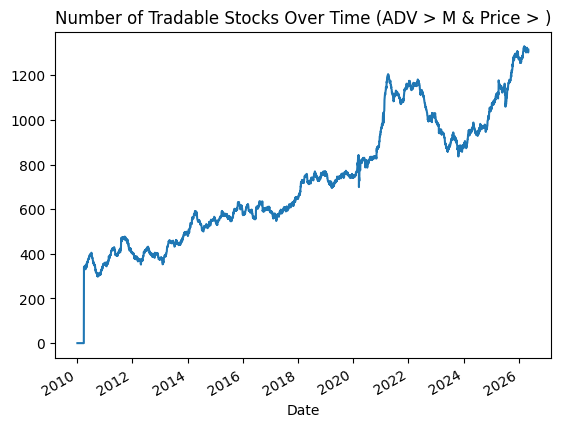

In [14]:
# Creating 5M+ Average Daily Volume and Price >  Universe
df_price_filter = (df_historical['Close'] > 1.0)
df_universe_5m = ((df_adv_60 > 5_000_000) & df_price_filter & er_mask & vol_mask).astype(int)
print('Universe shape:', df_universe_5m.shape)

df_universe_5m.sum(axis=1).plot(title="Number of Tradable Stocks Over Time (ADV > M & Price > )")

In [15]:
# Saving 5M universe to stores folder
# Drop any duplicated columns
df_universe_5m = df_universe_5m.loc[:, ~df_universe_5m.columns.duplicated()]
df_universe_5m.to_parquet(os.path.join(DATA_DIR, 'universe_5m.parquet'), engine='pyarrow')
print('Saved universe_5m.parquet')

Saved universe_5m.parquet


In [16]:
# Calculating returns for each ticker every day
# Using Close (which is now auto-adjusted) to account for dividends and stock splits
returns = df_historical['Close'].pct_change(fill_method=None).fillna(0)

In [17]:
# Saving returns to parquet file
# Drop any duplicated columns
returns = returns.loc[:, ~returns.columns.duplicated()]
returns.to_parquet(os.path.join(DATA_DIR, 'returns.parquet'), engine='pyarrow')
print('Saved returns.parquet')

Saved returns.parquet
